# Cascaded Tank Benchmark Code

In [1]:
from time import time
import casadi as ca
import numpy as np
from casadi import sin, cos, pi
import matplotlib.pyplot as plt

In [2]:
# Function for advancing simulation 

def shift_timestep(step_horizon, t0, state_init, u, f):
    f_value = f(state_init, u[:, 0])
    next_state = ca.DM.full(state_init + (step_horizon * f_value))

    t0 = t0 + step_horizon
    u0 = ca.horzcat(
        u[:, 1:],
        ca.reshape(u[:, -1], -1, 1)
    )

    return t0, next_state, u0


def DM2Arr(dm):
    return np.array(dm.full())

CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 119, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 119, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 119, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 119, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 119, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 119, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-01-27 13:40:01 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

0
0.012856006622314453
1
0.018346309661865234
2
0.010567188262939453
3
0.010002851486206055
4
0.009999275207519531
5
0.0032558441162109375
6
0.017182350158691406
7
0.010001420974731445
8
0.009997367858886719
9
0.008997440338134766
10
0.0019659996032714844
11
0.018975257873535156
12
0.009143829345703125
13
0.01098322868347168
14
0.011208772659301758
15
0.010999441146850586
16
0.009998321533203125
17
0.010001420974731445
18
0.0030934810638427734
19
0.015652179718017578
20
0.0
21
0.027576446533203125
22
0.01799941062927246
23
0.016000032424926758
24
0.012546062469482422
25
0.011001825332641602
26
0.00899815559387207
27
0.004825115203857422
28
0.01503753662109375
29
0.01028895378112793
30
0.00998544692993164
31
0.010013580322265625
32
0.00878453254699707
33
0.013074398040771484
34
0.010102510452270508
35
0.009999275207519531
36
0.008997440338134766
37
0.003908395767211914
38
0.018056869506835938
39
0.010256528854370117
40
0.010989189147949219
41
0.010005950927734375
42
0.01088857650756836


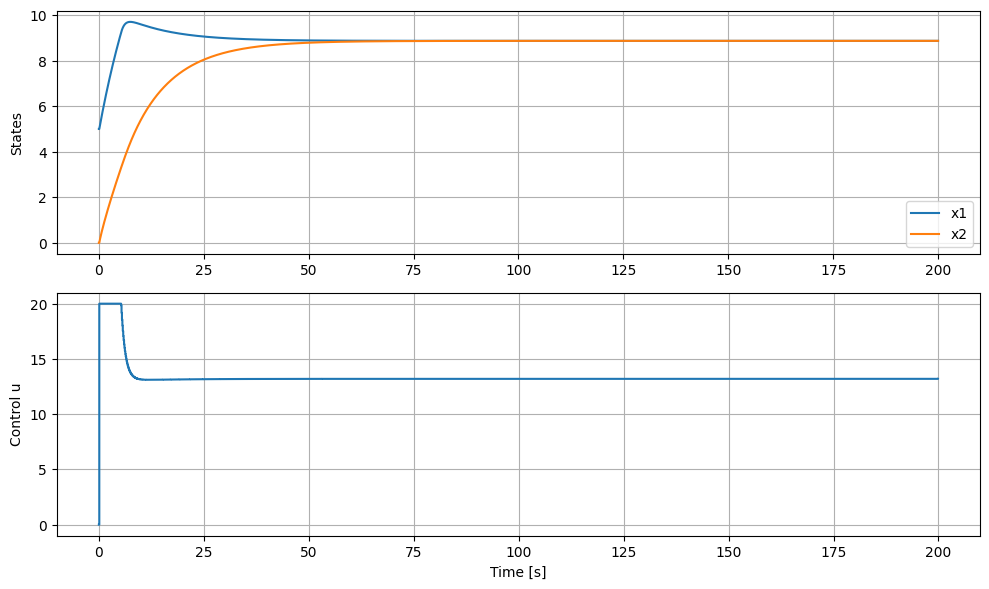

In [ ]:
# Define parameters for the cascaded tank system
k = 100 # unit conversion
rho = 1000 # density of fluid
g0 = 9.82 # gravity
A1 = 1.0 # area of tank 1
A2  = 1.0 # area of tank 2
a1 = 0.1 # area of tube 1
a2 = 0.1 # area of tube 2

T = 20 # time horizon
N = 60 # number of control intervals
step_horizon = 0.1  # time between steps in seconds
sim_time = 200      # simulation time

# Bounds for control input
u_max = 20
u_min = 0

# Initial state
x1_init = 5
x2_init = 0

# Reference
x1_target = 8 
x2_target = 12


# Symbolic variables
x = ca.MX.sym('x',2) # States
u = ca.MX.sym('u') # Controls
n_states = x.numel()
n_controls = u.numel()

# ODEs (plant model)
eps = 1e-6 # numeric stability 
ode = ca.vertcat(
    k/(rho*A1) * u - a1/A1 * ca.sqrt(2*g0*x[0] + eps), 
    a1/(A1) * ca.sqrt(2*g0*x[0] + eps) - a2/A2 * ca.sqrt(2*g0*x[1] + eps)
              )

# A matrix that contains all states over time (+1) where each column is a state vector
X = ca.SX.sym('X', n_states, N + 1)

# A matrix that contains all control inputs over time where each column is a control input
U = ca.SX.sym('U', n_controls, N)

# coloumn vector for storing initial state and target state
ref = ca.SX.sym('ref', 2*n_states)

# State and control weight matrices used in cost function
w1 = 1.0 # weight on state 1
w2 = 5.0 # weight on state 2
Q = ca.diagcat(w1, w2)

R = 0.01 # a scalar because we only have one control input

# Basically the state update should be next
# State update function
f = ca.Function('f', [x, u], [ode], ['x', 'u'], ['ode'])


# Initialize the cost function and cosntraints
cost_fn = 0  # cost function
g = X[:, 0] -ref[0:n_states]  # constraints in the equation


# RK method for integration
for k in range(N):
    st = X[:, k]
    con = U[:, k]
    cost_fn = cost_fn \
        + (st - ref[n_states:2*n_states]).T @ Q @ (st - ref[n_states:2*n_states]) \
        + con.T @ R @ con
    st_next = X[:, k+1]
    k1 = f(st, con)
    k2 = f(st + step_horizon/2*k1, con)
    k3 = f(st + step_horizon/2*k2, con)
    k4 = f(st + step_horizon * k3, con)
    st_next_RK4 = st + (step_horizon / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    g = ca.vertcat(g, st_next - st_next_RK4)

# Now we create the solver
# Below does the format where it maps the variables to a single vector (all states all timesteps)
OPT_variables = ca.vertcat(
    X.reshape((-1, 1)),   
    U.reshape((-1, 1))
)

# This creates the NLP problem to be solved
nlp_prob = {
    'f': cost_fn,
    'x': OPT_variables,
    'g': g,
    'p': ref
}

# Parameters for creating the solver
opts = {
    'ipopt': {
        'max_iter': 2000,
        'print_level': 0,
        'acceptable_tol': 1e-8,
        'acceptable_obj_change_tol': 1e-6
    },
    'print_time': 0
}

# Create the solver
solver = ca.nlpsol('solver', 'ipopt', nlp_prob, opts)

# Now for the constraints
lbx = ca.DM.zeros((n_states*(N+1) + n_controls*N, 1))
ubx = ca.DM.zeros((n_states*(N+1) + n_controls*N, 1))

lbx[0: n_states*(N+1): n_states] = -ca.inf     # x1 lower bound
lbx[1: n_states*(N+1): n_states] = -ca.inf     # x2 lower bound

ubx[0: n_states*(N+1): n_states] = ca.inf      # x1 upper bound
ubx[1: n_states*(N+1): n_states] = ca.inf      # x2 upper bound

lbx[n_states*(N+1):] = u_min                  # u lower bound for all u
ubx[n_states*(N+1):] = u_max                  # u upper bound for all u

# Constraint argument
args = {
    'lbg': ca.DM.zeros((n_states*(N+1), 1)),  # constraints lower bound
    'ubg': ca.DM.zeros((n_states*(N+1), 1)),  # constraints upper bound
    'lbx': lbx,
    'ubx': ubx
}

t0 = 0
state_init = ca.DM([x1_init, x2_init])        # initial state
state_target = ca.DM([x1_target, x2_target])  # reference state

# Initialize time
t = ca.DM(t0)

u0 = ca.DM.zeros((n_controls, N))  # initial control
X0 = ca.repmat(state_init, 1, N+1)         # initial state full

# Collector variables
mpc_iter = 0
cat_states = DM2Arr(X0)
cat_controls = DM2Arr(u0[:, 0])
times = np.array([[0]])

# The executive function
if __name__ == '__main__':
    main_loop = time()  # return time in sec
    while (ca.norm_2(state_init - state_target) > 1e-1) and (mpc_iter * step_horizon < sim_time):
        t1 = time()
        args['p'] = ca.vertcat(
            state_init,    # current state
            state_target   # target state
        )
        # optimization variable current state
        args['x0'] = ca.vertcat(
            ca.reshape(X0, n_states*(N+1), 1),
            ca.reshape(u0, n_controls*N, 1)
        )

        sol = solver(
            x0=args['x0'],
            lbx=args['lbx'],
            ubx=args['ubx'],
            lbg=args['lbg'],
            ubg=args['ubg'],
            p=args['p']
        )

        u = ca.reshape(sol['x'][n_states * (N + 1):], n_controls, N)
        X0 = ca.reshape(sol['x'][: n_states * (N+1)], n_states, N+1)

        cat_states = np.dstack((
            cat_states,
            DM2Arr(X0)
        ))

        cat_controls = np.vstack((
            cat_controls,
            DM2Arr(u[:, 0])
        ))
        t = np.vstack((
            t,
            t0
        ))

        t0, state_init, u0 = shift_timestep(step_horizon, t0, state_init, u, f)

        # print(X0)
        X0 = ca.horzcat(
            X0[:, 1:],
            ca.reshape(X0[:, -1], -1, 1)
        )

        # xx ...
        t2 = time()
        print(mpc_iter)
        print(t2-t1)
        times = np.vstack((
            times,
            t2-t1
        ))

        mpc_iter = mpc_iter + 1

    main_loop_time = time()
    ss_error = ca.norm_2(state_init - state_target)

# Number of MPC steps
Tsim = cat_controls.shape[0] - 1
dt = step_horizon

# Extract closed-loop states (first column of X0 at each iteration)
X_log = np.zeros((n_states, Tsim+1))

for k in range(Tsim+1):
    X_log[:, k] = cat_states[:, 0, k]

# Extract applied controls
U_log = cat_controls[:Tsim].T   # shape (1, Tsim)

# Plotting
t_x = np.arange(Tsim+1) * dt
t_u = np.arange(Tsim) * dt

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t_x, X_log[0,:], label='x1')
plt.plot(t_x, X_log[1,:], label='x2')
plt.ylabel('States')
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.step(t_u, U_log[0,:], where='post')
plt.xlabel('Time [s]')
plt.ylabel('Control u')
plt.grid(True)

plt.tight_layout()
plt.show()

